# 필요한 라이브러리 불러오기

In [45]:
import math
import torch
import matplotlib.pyplot as plt

# ❶ -pi부터 pi사이에서 점을 1000개 추출

In [46]:
x = torch.linspace(-math.pi, math.pi, 9000)

# ❷ 실제 사인곡선에서 추출한 값으로 y 만들기

In [47]:
y = torch.sin(x)

# ❸ 임의의 가중치(계수)를 뽑아 예측용 y 만들기

In [48]:
a = torch.randn(())
b = torch.randn(())
c = torch.randn(())
d = torch.randn(())

# 사인 함수를 근사할 3차 다항식 정의

In [49]:
y_random = a * x**3 + b * x**2 + c * x + d

# 그래프 출력하기

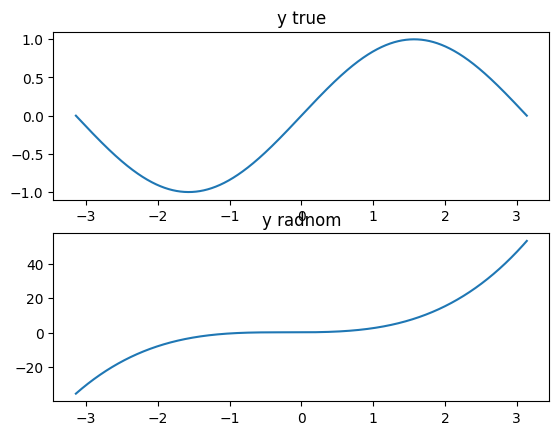

In [50]:
# ➍ 실제 y값으로 사인곡선 만들기
plt.subplot(2, 1, 1)
plt.title("y true")
plt.plot(x, y)

# ➎ 임의의 가중치로 만든 예측용 y값으로 사인곡선 만들기

plt.subplot(2, 1, 2)
plt.title("y radnom")
plt.plot(x, y_random)

# ➏ 그래프 출력하기
plt.show()

# 학습 전후 비교해보기

epoch1 loss:2589315.5
epoch101 loss:3530.58154296875
epoch201 loss:2860.31689453125
epoch301 loss:2381.933349609375
epoch401 loss:1984.724609375
epoch501 loss:1654.8760986328125
epoch601 loss:1380.962890625
epoch701 loss:1153.499755859375
epoch801 loss:964.6085205078125
epoch901 loss:807.7496337890625
epoch1001 loss:677.4898071289062
epoch1101 loss:569.3185424804688
epoch1201 loss:479.490478515625
epoch1301 loss:404.8941650390625
epoch1401 loss:342.9468688964844
epoch1501 loss:291.5036315917969
epoch1601 loss:248.78375244140625
epoch1701 loss:213.3079376220703
epoch1801 loss:183.8470458984375
epoch1901 loss:159.38157653808594
epoch2001 loss:139.0643768310547
epoch2101 loss:122.19135284423828
epoch2201 loss:108.17997741699219
epoch2301 loss:96.54440307617188
epoch2401 loss:86.88160705566406
epoch2501 loss:78.85709381103516
epoch2601 loss:72.19297790527344
epoch2701 loss:66.65876770019531
epoch2801 loss:62.06306076049805
epoch2901 loss:58.246368408203125
epoch3001 loss:55.076683044433594

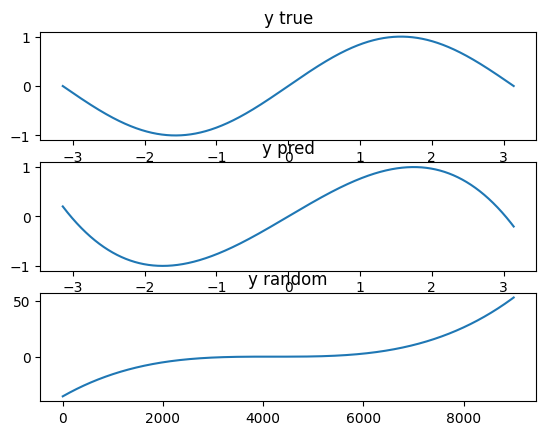

In [51]:
learning_rate = 1e-7 # 학습률 정의

for epoch in range(20000): # 학습 2000번 진행
   y_pred = a * x**3 + b * x**2 + c * x + d

   loss = (y_pred - y).pow(2).sum().item() # ❶ 손실 정의
   if epoch % 100 == 0:
       print(f"epoch{epoch+1} loss:{loss}")

   grad_y_pred = 2.0 * (y_pred - y) # ❷ 기울기의 미분값
   grad_a = (grad_y_pred * x ** 3).sum()
   grad_b = (grad_y_pred * x ** 2).sum()
   grad_c = (grad_y_pred * x).sum()
   grad_d = grad_y_pred.sum()

   a -= learning_rate * grad_a # ❸ 가중치 업데이트
   b -= learning_rate * grad_b
   c -= learning_rate * grad_c
   d -= learning_rate * grad_d

plt.subplot(3, 1, 1)
plt.title("y true")
plt.plot(x, y)
plt.subplot(3, 1, 2)
plt.title("y pred")
plt.plot(x, y_pred)
plt.subplot(3, 1, 3)
plt.plot(y_random)
plt.title("y random")
plt.show()